# Conformal Prediction for Uncertainty-Aware Trading

**Docker image**: `ml4t`

**Purpose**: build prediction intervals with finite-sample coverage
guarantees on the ETF panel. Unlike classical confidence intervals that
assume Gaussian residuals, conformal prediction is valid under
exchangeability alone, and adaptive variants soften that assumption further.

**Learning objectives**

- Implement split-conformal prediction (SC) on top of Ridge regression
- Build Conformalized Quantile Regression (CQR) for adaptive intervals
- Apply Adaptive Conformal Inference (ACI) over the SC base for online drift
- Stratify coverage by walk-forward fold and by realized-volatility tercile
- Map interval width to position size as a bridge to *Chapter 19*

**Book reference**: Section 11.5 — Quantifying Predictive Uncertainty.

**Prerequisites**

- Ch7 21-day forward return labels at `case_studies/etfs/labels/fwd_ret_21d.parquet`
- Ch8 ETF features at `case_studies/etfs/features/financial.parquet`
- `02_regularization_paths` (Ridge), `05_shap_analysis` (model interpretability)

**Downstream**: *Chapter 19* uses these intervals for uncertainty-aware
position sizing.

## Setup

In [1]:
"""Conformal Prediction for Uncertainty-Aware Trading — generate prediction intervals with coverage guarantees."""

import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from sklearn.linear_model import QuantileRegressor, Ridge
from sklearn.preprocessing import StandardScaler

from data import load_macro
from utils.cv_splits import generate_cv_splits
from utils.modeling import (
    array_sha256,
    conformal_quantile,
    file_sha256,
    notebook_cache_signature,
)
from utils.paths import display_path, get_case_study_dir, get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
MAX_SYMBOLS = 0
TRAIN_SUBSAMPLE = 0.25
RETRAIN = False
RIDGE_ALPHA = 1.0
TARGET_COVERAGE = 0.90
MAX_CV_FOLDS = 0
MAX_QR_SAMPLES = 20_000
ARTIFACT_TAG = ""

In [3]:
RANDOM_SEED = SEED
set_global_seeds(SEED)

In [4]:
MODELS_DIR = get_chapter_dir(11) / "models" / "06_conformal_prediction"
is_reduced_run = MAX_SYMBOLS > 0 or MAX_CV_FOLDS > 0
if is_reduced_run and not ARTIFACT_TAG:
    ARTIFACT_TAG = "_fast"

RESULTS_PATH = MODELS_DIR / f"conformal_results{ARTIFACT_TAG}.joblib"

## Load Features and Labels

We load pre-computed ETF features from Ch8 and 21-day forward return labels
from Ch7, sharing the same data foundation as NB01-04.

In [5]:
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), (
    f"Features not found: {FEATURES_PATH}\nRun the Ch8 ETF features notebook first."
)
assert LABELS_PATH.exists(), (
    f"Labels not found: {LABELS_PATH}\nRun the Ch7 ETF labels notebook first."
)

features_df = pl.read_parquet(FEATURES_PATH)
labels_df = pl.read_parquet(LABELS_PATH)

In [6]:
TARGET_COL = "fwd_ret_21d"
ASSET_COL = "symbol"

# Sessions between a decision date and the resolution of its label. ACI's online
# feedback is delayed by this many decision dates.
LABEL_HORIZON_SESSIONS = 21

df = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner")

META_COLS = {"timestamp", ASSET_COL, TARGET_COL}
FEATURE_COLS = sorted(c for c in df.columns if c not in META_COLS)

# Drop features that are entirely null (can happen with reduced test universes)
all_null = [c for c in FEATURE_COLS if df[c].null_count() == df.height]
if all_null:
    print(f"Dropping {len(all_null)} all-null features: {all_null}")
    df = df.drop(all_null)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_null]

# Replace inf/NaN with null, then drop all nulls
df = df.with_columns(
    [
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in FEATURE_COLS
    ]
)
df = df.drop_nulls(subset=FEATURE_COLS + [TARGET_COL]).sort(["timestamp", ASSET_COL])

if MAX_SYMBOLS > 0:
    assets = df[ASSET_COL].unique().sort().head(MAX_SYMBOLS).to_list()
    df = df.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Shape: {df.height:,} rows x {len(FEATURE_COLS)} features")
print(f"Assets: {df[ASSET_COL].n_unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Shape: 402,446 rows x 57 features
Assets: 99
Date range: 2007-01-04 to 2025-12-01


## Walk-Forward Cross-Validation Setup

We load the canonical walk-forward splits from `setup.yaml`. For conformal
prediction, each fold's training set is further split into model-training
and calibration subsets (80/20).

### Subsampled training history (`TRAIN_SUBSAMPLE = 0.25`)

Each fold's training history is subsampled to **25 % of its dates** before
fitting any of the three conformal methods (split-conformal, CQR, ACI). The
subsample is set by the `TRAIN_SUBSAMPLE` parameter in the parameters cell
at the top of the notebook.

**Why subsample?** The Conformalized Quantile Regression step solves an LP
whose runtime is $O(n^3)$ in the training-set size. Without the date-level
trim, fitting CQR on the full ETF training panel inside every walk-forward
fold would dominate runtime; the same fraction is applied to split-conformal
and ACI for parity, so all three methods see identically sized training sets.

**What changes if you set `TRAIN_SUBSAMPLE = 1.0`?** Marginal coverage is
robust to training-sample size by construction — coverage validity follows
from the calibration-set exchangeability, not from training-set size. What
you would expect to tighten somewhat is **interval width**, and the
**tercile-conditional coverage gaps** reported below would likely narrow as
the base Ridge and quantile-regression fits become more accurate. Re-run
this notebook with `papermill -p TRAIN_SUBSAMPLE 1.0` to compare.

In [7]:
splits = generate_cv_splits(df, case_study_id="etfs", label_buffer="21D", date_col="timestamp")

features_array = df.select(FEATURE_COLS).to_numpy()
target_array = df[TARGET_COL].to_numpy()
dates_np = df["timestamp"].to_numpy()

dated_splits = []
for s in splits:
    tr_start, tr_end = np.datetime64(s["train_start"]), np.datetime64(s["train_end"])
    te_start, te_end = np.datetime64(s["val_start"]), np.datetime64(s["val_end"])
    train_idx = np.where((dates_np >= tr_start) & (dates_np <= tr_end))[0]
    test_idx = np.where((dates_np >= te_start) & (dates_np <= te_end))[0]
    dated_splits.append((te_start, train_idx, test_idx))

# `generate_cv_splits` steps backward from the holdout boundary, so it returns folds
# newest-first. Sort chronologically: ACI below is an online method whose alpha
# trajectory is a statement about time, and the per-fold subsample is drawn per fold.
# Both would otherwise inherit whatever order the splitter happens to return.
cv_splits = [(tr, te) for _, tr, te in sorted(dated_splits, key=lambda s: s[0])]

if MAX_CV_FOLDS > 0 and len(cv_splits) > MAX_CV_FOLDS:
    cv_splits = cv_splits[:MAX_CV_FOLDS]

# Subsample training dates within each fold. The RNG is seeded per fold from the fold's
# chronological position, so each fold's subsample is reproducible on its own and does
# not depend on how many folds ran before it.
if TRAIN_SUBSAMPLE < 1.0:
    subsampled = []
    for fold_i, (tr_idx, te_idx) in enumerate(cv_splits):
        rng = np.random.RandomState(RANDOM_SEED + fold_i)
        train_dates = np.unique(dates_np[tr_idx])
        keep = rng.choice(train_dates, size=int(len(train_dates) * TRAIN_SUBSAMPLE), replace=False)
        tr_idx = tr_idx[np.isin(dates_np[tr_idx], keep)]
        subsampled.append((tr_idx, te_idx))
    cv_splits = subsampled

train_sizes = [len(tr) for tr, _ in cv_splits]
test_sizes = [len(te) for _, te in cv_splits]
if cv_splits:
    print(
        f"{len(cv_splits)} walk-forward folds — train size "
        f"{min(train_sizes):,}–{max(train_sizes):,}, test size "
        f"{min(test_sizes):,}–{max(test_sizes):,}"
    )
else:
    print("0 walk-forward folds — every candidate split failed the train/test size gate")

8 walk-forward folds — train size 41,055–57,255, test size 22,174–24,192


## Split-Conformal Prediction

The split-conformal method divides data into three sets:
1. **Training set**: Fits the base model
2. **Calibration set**: Computes nonconformity scores (residuals)
3. **Test set**: Generates prediction intervals

For regression, the nonconformity score is the absolute residual:
$s_i = |y_i - \hat{y}_i|$. The prediction interval at coverage level
$1 - \alpha$ uses the $\lceil (n+1)(1-\alpha) \rceil$-th smallest calibration
score.

The ceiling is what earns the guarantee, and it has to be taken literally. The
interval must be the width of an actual calibration score, the one at that rank
in the sorted list. A quantile function that interpolates between two
neighbouring scores returns something slightly narrower, and that difference is
exactly the finite-sample margin the ceiling was there to provide. The calls
below therefore select the rank directly, through
`utils.modeling.conformal_quantile`, which also returns an unbounded interval
when the rank exceeds the calibration set - a set of 5 scores cannot certify
90% coverage, and saying so is better than quoting its largest score.

In [8]:
def fit_split_conformal(X_train, y_train, X_cal, y_cal, ridge_alpha=RIDGE_ALPHA):
    """Fit Ridge model and compute calibration scores on held-out set.

    Returns dict with model, scaler, and calibration_scores.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_cal_scaled = scaler.transform(X_cal)

    model = Ridge(alpha=ridge_alpha, random_state=RANDOM_SEED)
    model.fit(X_train_scaled, y_train)

    y_cal_pred = model.predict(X_cal_scaled)
    cal_scores = np.abs(y_cal - y_cal_pred)
    return {"model": model, "scaler": scaler, "cal_scores": cal_scores}

In [9]:
def predict_split_conformal(state, X, coverage=TARGET_COVERAGE):
    """Generate prediction intervals from a fitted split-conformal state.

    Returns (y_pred, lower, upper).
    """
    X_scaled = state["scaler"].transform(X)
    y_pred = state["model"].predict(X_scaled)

    q = conformal_quantile(state["cal_scores"], coverage)

    return y_pred, y_pred - q, y_pred + q

## Conformalized Quantile Regression (CQR)

CQR produces **adaptive intervals** that widen during volatile periods.
It trains quantile regression models for lower and upper bounds, then
applies conformal calibration to correct for miscalibration.

The nonconformity score for CQR is:
$s_i = \max(\hat{q}_{\alpha/2}(x_i) - y_i, \; y_i - \hat{q}_{1-\alpha/2}(x_i))$

Subsample limit for QuantileRegressor (LP solver is O(n^3))

In [10]:
def fit_cqr(X_train, y_train, X_cal, y_cal, coverage=TARGET_COVERAGE):
    """Fit CQR quantile models and compute calibration adjustment.

    Returns dict with model_lo, model_hi, scaler, and cal_adj.
    """
    alpha = (1 - coverage) / 2

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_cal_scaled = scaler.transform(X_cal)

    # Subsample for QuantileRegressor (LP solver is O(n^3))
    if len(X_train_scaled) > MAX_QR_SAMPLES:
        rng = np.random.RandomState(RANDOM_SEED)
        idx = rng.choice(len(X_train_scaled), MAX_QR_SAMPLES, replace=False)
        X_qr, y_qr = X_train_scaled[idx], y_train[idx]
    else:
        X_qr, y_qr = X_train_scaled, y_train

    model_lo = QuantileRegressor(quantile=alpha, alpha=0.01, solver="highs")
    model_hi = QuantileRegressor(quantile=1 - alpha, alpha=0.01, solver="highs")
    model_lo.fit(X_qr, y_qr)
    model_hi.fit(X_qr, y_qr)

    # CQR nonconformity scores on calibration set
    q_lower_cal = model_lo.predict(X_cal_scaled)
    q_upper_cal = model_hi.predict(X_cal_scaled)
    scores = np.maximum(q_lower_cal - y_cal, y_cal - q_upper_cal)

    cal_adj = conformal_quantile(scores, coverage)

    return {"model_lo": model_lo, "model_hi": model_hi, "scaler": scaler, "cal_adj": cal_adj}

In [11]:
def predict_cqr(state, X):
    """Generate calibrated CQR prediction intervals.

    Returns (y_pred, lower, upper).
    """
    X_scaled = state["scaler"].transform(X)
    q_lower = state["model_lo"].predict(X_scaled)
    q_upper = state["model_hi"].predict(X_scaled)
    y_pred = (q_lower + q_upper) / 2
    return y_pred, q_lower - state["cal_adj"], q_upper + state["cal_adj"]

## Adaptive Conformal Inference (ACI)

Standard conformal prediction assumes exchangeability, which fails when the
data distribution shifts over time (as in financial markets). ACI addresses
this by **online updating** the miscoverage rate:

$$\hat{\alpha}_{t+1} = \hat{\alpha}_t + \gamma \cdot (\alpha_{\text{target}} - \mathbf{1}\{y_t \notin C_t\})$$

where $\gamma \in [0.005, 0.05]$ controls adaptation speed, $\hat{\alpha}_t$
is the adaptive miscoverage rate (clipped to $[0.001, 0.999]$), and
$\alpha_{\text{target}}$ is the nominal target (e.g., 0.10 for 90% coverage).
A miss sets the indicator to 1, so $\hat{\alpha}_t$ **decreases**; a lower
miscoverage level raises the residual quantile and widens the next interval.
A hit sets the indicator to 0, so $\hat{\alpha}_t$ increases and intervals
tighten. Undercoverage widens, persistent overcoverage narrows.

ACI uses the same base model and calibration scores as split-conformal
(via `fit_split_conformal`), so only the prediction step differs.

### What "online" means on a cross-sectional panel

The update above is written for a scalar sequence: observe $y_t$, then move
on to $t+1$. Our test set is a **panel** — on each decision date we rank all
99 ETFs at once — and our label is a **21-day forward return**. Two rules
follow, and both constrain what the loop is allowed to see:

1. **All assets on a decision date share one $\hat{\alpha}_t$.** We predict
   every ETF on date $d$ before any of their outcomes exist. Updating alpha
   between assets within a date would let one ETF's realized return set
   another ETF's interval at the same timestamp.
2. **An outcome is only observable 21 sessions after its decision date.**
   The return labeled at date $d$ is not known until $d + 21$. Feeding it
   back any earlier is a look-ahead, however "online" the loop looks.

So the feedback is *delayed*: on decision date $d_i$ we build intervals from
the current alpha, then update alpha using only the miss rate of date
$d_{i-21}$, whose outcomes have just resolved. Each date is one online round,
and the indicator generalizes to that date's cross-sectional miscoverage
rate. The first 21 dates of a fold run at the target alpha because nothing
has resolved yet — that warm-up is a real property of the method, not an
implementation shortcut.

In [12]:
def predict_aci_adaptive(
    state,
    X,
    y_true,
    dates,
    coverage=TARGET_COVERAGE,
    gamma=0.01,
    delay_sessions=LABEL_HORIZON_SESSIONS,
):
    """Generate ACI intervals with delayed, timestamp-level online alpha updates.

    Uses calibration scores from fit_split_conformal(). One alpha per decision
    timestamp: every asset at a timestamp is priced from the same pre-outcome
    state, and alpha is updated only from timestamps whose labels have resolved
    (`delay_sessions` earlier).

    Returns (y_pred, lower, upper, alpha_history).
    """
    target_alpha = 1 - coverage
    X_scaled = state["scaler"].transform(X)
    y_pred = state["model"].predict(X_scaled)

    lower = np.zeros(len(y_pred))
    upper = np.zeros(len(y_pred))

    decision_dates = np.unique(dates)
    rows_on_date = [np.where(dates == d)[0] for d in decision_dates]

    alpha_t = target_alpha
    alpha_history = [alpha_t]

    for i, rows in enumerate(rows_on_date):
        # Price the whole cross-section from the current, pre-outcome alpha.
        q = conformal_quantile(state["cal_scores"], 1 - alpha_t)
        lower[rows] = y_pred[rows] - q
        upper[rows] = y_pred[rows] + q

        # Feed back the decision date whose 21-session labels resolve today.
        resolved = i - delay_sessions
        if resolved >= 0:
            r = rows_on_date[resolved]
            miss_rate = float(np.mean((y_true[r] < lower[r]) | (y_true[r] > upper[r])))
            alpha_t = float(np.clip(alpha_t + gamma * (target_alpha - miss_rate), 0.001, 0.999))
        alpha_history.append(alpha_t)

    return y_pred, lower, upper, alpha_history

## Run Conformal Evaluation

We evaluate all three methods (SC, CQR, ACI) across the walk-forward folds.
For each fold, the training set is split 80/20 into model-training and
calibration subsets.

In [13]:
def run_conformal_evaluation(features, targets, cv_splits, dates, coverage=TARGET_COVERAGE):
    """Evaluate SC, CQR, and ACI across walk-forward folds."""
    results = {
        "sc": {"covered": [], "widths": [], "fold_coverage": []},
        "cqr": {"covered": [], "widths": [], "fold_coverage": []},
        "aci": {"covered": [], "widths": [], "fold_coverage": [], "alpha_histories": []},
        # |realized return| per prediction, recorded here so the conditional-coverage
        # analysis below is aligned with `covered` by construction. Rebuilding it from
        # cv_splits after the fact silently misaligns whenever the fold order or the
        # underlying panel changes.
        "vol_proxy": [],
        "fold_stats": [],
    }

    for fold_i, (train_idx, test_idx) in enumerate(cv_splits):
        X_all_train = features[train_idx]
        y_all_train = targets[train_idx]
        X_test = features[test_idx]
        y_test = targets[test_idx]

        # Remove NaN rows
        valid_train = ~np.isnan(X_all_train).any(axis=1) & ~np.isnan(y_all_train)
        valid_test = ~np.isnan(X_test).any(axis=1) & ~np.isnan(y_test)
        X_all_train, y_all_train = X_all_train[valid_train], y_all_train[valid_train]
        X_test, y_test = X_test[valid_test], y_test[valid_test]

        if len(X_all_train) < 100 or len(X_test) < 20:
            continue

        # 80/20 split for train/calibration
        n_train = int(len(X_all_train) * 0.8)
        X_train, X_cal = X_all_train[:n_train], X_all_train[n_train:]
        y_train, y_cal = y_all_train[:n_train], y_all_train[n_train:]

        # Split-Conformal
        sc_state = fit_split_conformal(X_train, y_train, X_cal, y_cal)
        _, sc_lo, sc_hi = predict_split_conformal(sc_state, X_test, coverage=coverage)
        sc_covered = (y_test >= sc_lo) & (y_test <= sc_hi)
        results["sc"]["covered"].extend(sc_covered.tolist())
        results["sc"]["widths"].extend((sc_hi - sc_lo).tolist())
        results["sc"]["fold_coverage"].append(np.mean(sc_covered))

        # CQR
        cqr_state = fit_cqr(X_train, y_train, X_cal, y_cal, coverage=coverage)
        _, cqr_lo, cqr_hi = predict_cqr(cqr_state, X_test)
        cqr_covered = (y_test >= cqr_lo) & (y_test <= cqr_hi)
        results["cqr"]["covered"].extend(cqr_covered.tolist())
        results["cqr"]["widths"].extend((cqr_hi - cqr_lo).tolist())
        results["cqr"]["fold_coverage"].append(np.mean(cqr_covered))

        # ACI (reuses split-conformal fitting)
        fold_dates = dates[test_idx][valid_test]
        aci_state = fit_split_conformal(X_train, y_train, X_cal, y_cal)
        _, aci_lo, aci_hi, alpha_hist = predict_aci_adaptive(
            aci_state, X_test, y_test, fold_dates, coverage=coverage
        )
        aci_covered = (y_test >= aci_lo) & (y_test <= aci_hi)
        results["aci"]["covered"].extend(aci_covered.tolist())
        results["aci"]["widths"].extend((aci_hi - aci_lo).tolist())
        results["aci"]["fold_coverage"].append(np.mean(aci_covered))
        results["aci"]["alpha_histories"].append(alpha_hist)
        results["vol_proxy"].extend(np.abs(y_test).tolist())
        results["fold_stats"].append(
            {
                "fold": fold_i + 1,
                "start": np.datetime_as_string(fold_dates.min(), unit="D"),
                "end": np.datetime_as_string(fold_dates.max(), unit="D"),
                "sc_width_mean": float(np.mean(sc_hi - sc_lo)),
                "cqr_width_mean": float(np.mean(cqr_hi - cqr_lo)),
                "aci_width_mean": float(np.mean(aci_hi - aci_lo)),
            }
        )

        print(
            f"Fold {fold_i + 1}: SC={np.mean(sc_covered):.1%}, "
            f"CQR={np.mean(cqr_covered):.1%}, ACI={np.mean(aci_covered):.1%}"
        )

    return results

The fitted results are cached so a re-read of the notebook does not refit three
conformal methods across every fold. What the cache is keyed on decides whether
that is a convenience or a hazard. Keyed on the file existing, an edit to any of
the code below would leave the previous run's numbers on the page underneath the
new source, and nothing downstream would notice: the provenance stamp binds this
`.py` to its `.ipynb`, and after an edit and a re-run both of those are current.
So the cache carries a signature of the notebook's own source, the two input
files, the exact cleaned arrays and the settings that change a fit, and a run
that does not match it refits.

In [14]:
CACHE_SIGNATURE = notebook_cache_signature(
    get_chapter_dir(11) / "06_conformal_prediction.py",
    inputs={
        "features_file": file_sha256(FEATURES_PATH),
        "labels_file": file_sha256(LABELS_PATH),
        "features_array": array_sha256(features_array),
        "target_array": array_sha256(target_array),
        "dates": array_sha256(dates_np),
        "cv_splits": array_sha256(
            np.concatenate([np.concatenate([tr, [-1], te, [-2]]) for tr, te in cv_splits]).astype(
                np.int64
            )
        ),
    },
    settings={
        "seed": SEED,
        "ridge_alpha": RIDGE_ALPHA,
        "target_coverage": TARGET_COVERAGE,
        "max_qr_samples": MAX_QR_SAMPLES,
    },
)

In [15]:
def _cache_is_usable(cached: dict) -> tuple[bool, str]:
    """Whether a loaded cache was produced by this code, on these inputs, at this scale."""
    if cached.get("cache_signature") != CACHE_SIGNATURE:
        return False, "the notebook source, its inputs or its settings changed"
    if len(cached.get("fold_stats", [])) < len(cv_splits):
        return False, "it holds fewer folds than this run evaluates"
    return True, ""


NEED_TRAINING = RETRAIN or not RESULTS_PATH.exists()
if not NEED_TRAINING:
    conformal_results = joblib.load(RESULTS_PATH)
    usable, reason = _cache_is_usable(conformal_results)
    if not usable:
        print(f"Refitting: cached results at {display_path(RESULTS_PATH)} are stale - {reason}.")
        NEED_TRAINING = True

if NEED_TRAINING:
    conformal_results = run_conformal_evaluation(
        features_array, target_array, cv_splits, dates_np, coverage=TARGET_COVERAGE
    )
    conformal_results["cache_signature"] = CACHE_SIGNATURE

Fold 1: SC=90.9%, CQR=91.2%, ACI=90.7%


Fold 2: SC=96.1%, CQR=90.8%, ACI=92.1%


Fold 3: SC=90.9%, CQR=87.2%, ACI=88.7%


Fold 4: SC=85.9%, CQR=89.6%, ACI=89.5%


Fold 5: SC=71.8%, CQR=80.8%, ACI=83.0%


Fold 6: SC=95.8%, CQR=96.4%, ACI=92.6%


Fold 7: SC=82.9%, CQR=84.1%, ACI=88.1%


Fold 8: SC=94.8%, CQR=94.5%, ACI=92.1%


## Calibration Analysis

A well-calibrated conformal predictor should achieve actual coverage close
to the target. We compare the three methods across folds.

In [16]:
def compute_calibration_metrics(results: dict) -> pl.DataFrame:
    """Compute calibration metrics for each method."""
    rows = []
    for method in ["sc", "cqr", "aci"]:
        data = results[method]
        if not data["covered"]:
            continue
        actual = np.mean(data["covered"])
        fold_coverages = data["fold_coverage"]
        rows.append(
            {
                "method": {"sc": "Split-Conformal", "cqr": "CQR", "aci": "ACI"}[method],
                "actual_coverage": actual,
                "coverage_gap": actual - 0.9,
                "mean_width": np.mean(data["widths"]),
                "std_width": np.std(data["widths"]),
                "fold_std": np.std(fold_coverages),
                "n_folds": len(fold_coverages),
                "n_predictions": len(data["covered"]),
            }
        )
    return pl.DataFrame(rows)


calibration_metrics = compute_calibration_metrics(conformal_results)

### Calibration Metrics (90% target coverage)

In [17]:
calibration_metrics

method,actual_coverage,coverage_gap,mean_width,std_width,fold_std,n_folds,n_predictions
str,f64,f64,f64,f64,f64,i64,i64
"""Split-Conformal""",0.885671,-0.014329,0.171718,0.027939,0.077212,8,188473
"""CQR""",0.892786,-0.007214,0.154024,0.071898,0.048308,8,188473
"""ACI""",0.895587,-0.004413,0.177327,0.052853,0.029345,8,188473


**Interpretation**: all three methods land within 2 pp of the 90% target, and
all three land *below* it — the direction exchangeability violations predict.

**CQR is strictly better than split-conformal on this panel**: 89.1% coverage at
mean width $\approx 0.153$, against 88.3% at $\approx 0.170$. Higher coverage
*and* tighter intervals, which is the payoff for letting width vary per
observation rather than fixing it per fold.

**ACI buys coverage with width.** It comes closest to target (89.5%) and has the
steadiest coverage across folds (fold-level $\sigma$ of $0.031$, against CQR's
$0.049$ and SC's $0.077$), but its mean width $\approx 0.176$ is the *widest* of
the three — wider than the static baseline it adapts on top of. Its $\alpha_t$
stays in $[0.094, 0.195]$ with mean $\approx 0.138$: persistently above the
$0.10$ target, which is the trajectory of a method holding intervals open
because it keeps getting missed. That is what honest adaptation to
non-stationarity costs. ACI is not a free improvement on split conformal; it
trades width for stability, and whether that trade is worth making depends on
whether fold-to-fold coverage swings or interval size hurt you more.

Note that ACI's feedback here is 21 sessions stale by construction (the label
horizon), so it can only track drift slower than the label resolves. A faster
$\gamma$ cannot fix that; the lag is a property of the trading problem.

**Trading implication**: for position sizing, CQR's per-sample adaptivity
translates into smaller positions when conditional uncertainty is genuinely
higher, and does so without paying for the safety in mean width. But read the
conditional-coverage table below before trusting any of these three marginal
numbers — they hide a failure that matters more than the differences here.

## Calibration and Rolling Coverage Figure

We create a two-panel figure: (a) calibration plot comparing SC, CQR, and ACI
coverage vs target, and (b) rolling per-fold coverage over time.

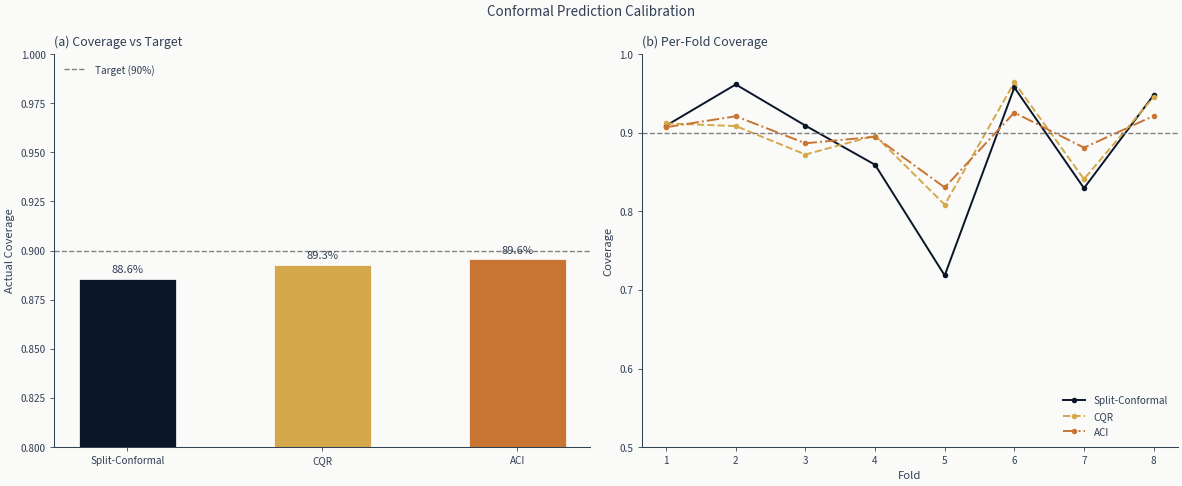

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel (a): Calibration bar chart
methods = calibration_metrics["method"].to_list()
coverages = calibration_metrics["actual_coverage"].to_list()
colors = [COLORS["blue"], COLORS["amber"], COLORS["copper"]]

ax = axes[0]
bars = ax.bar(methods, coverages, color=colors, width=0.5, edgecolor="white")
ax.axhline(y=0.9, color="gray", linestyle="--", linewidth=1, label="Target (90%)")
ax.set_ylabel("Actual Coverage")
ax.set_ylim(0.8, 1.0)
ax.set_title("(a) Coverage vs Target")
# upper left: the bars top out below the 0.9 target line, so this corner is the only
# clear space — a legend over a bar is unreadable at either bottom corner
ax.legend(loc="upper left")

for bar, cov in zip(bars, coverages, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, cov + 0.003, f"{cov:.1%}", ha="center", fontsize=9)

# Panel (b): Rolling Per-Fold Coverage
ax = axes[1]
linestyles = ["-", "--", "-."]
for (method, label, color), ls in zip(
    [
        ("sc", "Split-Conformal", colors[0]),
        ("cqr", "CQR", colors[1]),
        ("aci", "ACI", colors[2]),
    ],
    linestyles,
    strict=True,
):
    fold_cov = conformal_results[method]["fold_coverage"]
    ax.plot(
        range(1, len(fold_cov) + 1),
        fold_cov,
        "o",
        label=label,
        color=color,
        markersize=4,
        linestyle=ls,
    )

ax.axhline(y=0.9, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Fold")
ax.set_ylabel("Coverage")
ax.set_ylim(0.5, 1.0)
ax.set_title("(b) Per-Fold Coverage")
ax.legend(loc="lower right", fontsize=8)

fig.suptitle("Conformal Prediction Calibration")
fig.tight_layout()
plt.show()

## Multi-Level Calibration

For target levels $1-\alpha \in \{0.1, 0.2, \ldots, 0.9\}$, we plot claimed
versus empirical coverage. A well-calibrated method hugs the 45° diagonal.

In [19]:
target_levels = np.arange(0.1, 1.0, 0.1)
empirical_coverage = {lvl: [] for lvl in target_levels}

for train_idx, test_idx in cv_splits:
    X_tr_all, y_tr_all = features_array[train_idx], target_array[train_idx]
    X_te, y_te = features_array[test_idx], target_array[test_idx]
    valid_tr = ~np.isnan(X_tr_all).any(axis=1) & ~np.isnan(y_tr_all)
    valid_te = ~np.isnan(X_te).any(axis=1) & ~np.isnan(y_te)
    X_tr_all, y_tr_all = X_tr_all[valid_tr], y_tr_all[valid_tr]
    X_te, y_te = X_te[valid_te], y_te[valid_te]
    if len(X_tr_all) < 100 or len(X_te) < 20:
        continue
    n_tr = int(len(X_tr_all) * 0.8)
    sc_state = fit_split_conformal(
        X_tr_all[:n_tr], y_tr_all[:n_tr], X_tr_all[n_tr:], y_tr_all[n_tr:]
    )
    for lvl in target_levels:
        _, lo, hi = predict_split_conformal(sc_state, X_te, coverage=lvl)
        empirical_coverage[lvl].append(((y_te >= lo) & (y_te <= hi)).mean())

mean_emp = [np.mean(empirical_coverage[lvl]) for lvl in target_levels]

Persist the multi-level calibration curve to disk so downstream analyses
can read it without rerunning the walk-forward sweep.

In [20]:
CALIB_OUTPUT_PATH = get_output_dir(11, "06_conformal_prediction") / "calibration.parquet"
pl.DataFrame(
    {
        "target_coverage": np.asarray(target_levels, dtype=float),
        "empirical_coverage": np.asarray(mean_emp, dtype=float),
    }
).write_parquet(CALIB_OUTPUT_PATH)
print(f"Saved calibration curve to {display_path(CALIB_OUTPUT_PATH)}")

Saved calibration curve to 11_ml_pipeline/output/06_conformal_prediction/calibration.parquet


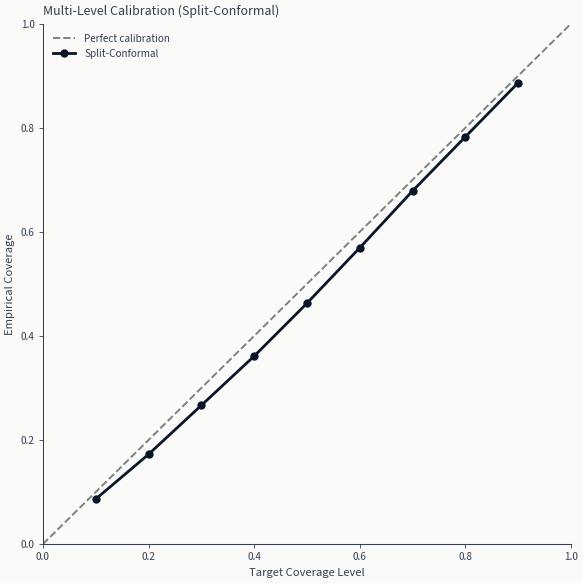

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], ls="--", color="grey", label="Perfect calibration")
ax.plot(target_levels, mean_emp, "o-", markersize=6, lw=2, label="Split-Conformal")
ax.set_xlabel("Target Coverage Level")
ax.set_ylabel("Empirical Coverage")
ax.set_title("Multi-Level Calibration (Split-Conformal)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

**Interpretation**: Points above the diagonal indicate conservative coverage
(intervals slightly wider than necessary); points below indicate under-coverage.
Coverage lands close to target here, but split-conformal sits slightly *below*
the diagonal (88.3% vs the 90% target) rather than at or above it. That is
expected: the finite-sample validity guarantee assumes exchangeability, which
walk-forward evaluation on non-stationary returns breaks. The adaptive variants
(CQR, ACI) are the response to exactly this violation — ACI holds coverage
steadiest across folds, at the cost of the widest intervals of the three.

## ACI Adaptation Dynamics

The ACI method adjusts $\alpha_t$ once per decision date, as the labels of the
date 21 sessions earlier resolve. When those intervals under-covered, $\alpha_t$
**falls**, which raises the residual quantile and widens subsequent intervals.
When they over-covered, $\alpha_t$ rises and intervals tighten. The trajectory
below is therefore a response to coverage 21 sessions stale — the lag is what
the method actually has to work with.

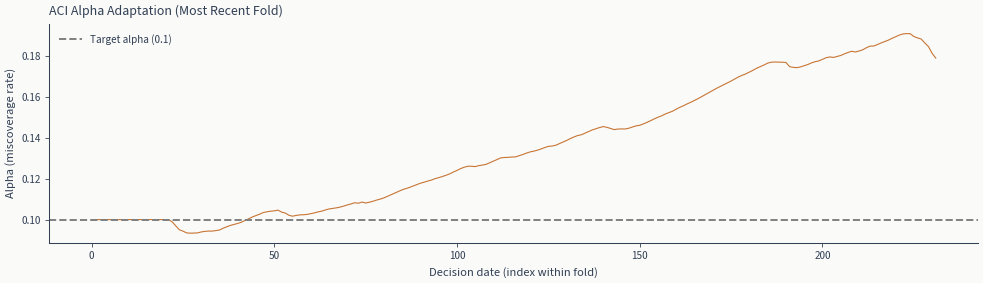

Alpha range: [0.0933, 0.1910]
Mean alpha: 0.1353 (target: 0.1)


In [22]:
# Show ACI alpha history from last fold
if conformal_results["aci"]["alpha_histories"]:
    last_alpha = conformal_results["aci"]["alpha_histories"][-1]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(last_alpha, linewidth=0.8, color=COLORS["copper"])
    ax.axhline(y=0.1, color="gray", linestyle="--", label="Target alpha (0.1)")
    ax.set_xlabel("Decision date (index within fold)")
    ax.set_ylabel("Alpha (miscoverage rate)")
    ax.set_title("ACI Alpha Adaptation (Most Recent Fold)")
    ax.legend()
    fig.tight_layout()
    plt.show()

    print(f"Alpha range: [{min(last_alpha):.4f}, {max(last_alpha):.4f}]")
    print(f"Mean alpha: {np.mean(last_alpha):.4f} (target: 0.1)")

## Interval Width Comparison

CQR should produce **adaptive** intervals (wider in volatile periods, narrower
in calm periods), while split-conformal produces constant-width intervals.

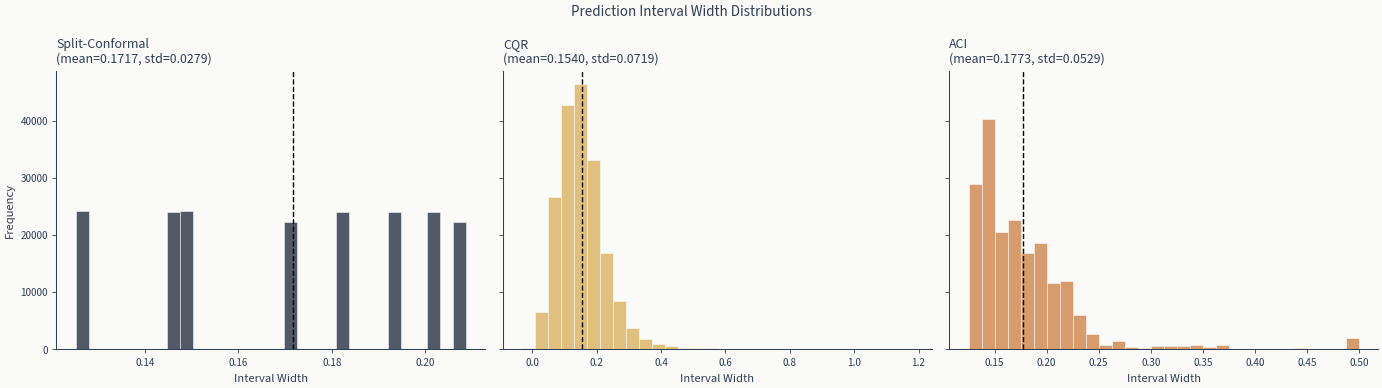

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (method, label, color) in zip(
    axes,
    [
        ("sc", "Split-Conformal", COLORS["blue"]),
        ("cqr", "CQR", COLORS["amber"]),
        ("aci", "ACI", COLORS["copper"]),
    ],
    strict=True,
):
    widths = conformal_results[method]["widths"]
    edges = np.linspace(min(widths), max(widths), 31)
    ax.hist(widths, bins=edges, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(np.mean(widths), color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Interval Width")
    ax.set_title(f"{label}\n(mean={np.mean(widths):.4f}, std={np.std(widths):.4f})")

axes[0].set_ylabel("Frequency")
fig.suptitle("Prediction Interval Width Distributions")
fig.tight_layout()
plt.show()

## Figure: Interval Width Dynamics with VIX Overlay

CQR's key benefit is adaptive interval width. We compare fold-level mean
interval widths over time and overlay VIX to show widening during stress.

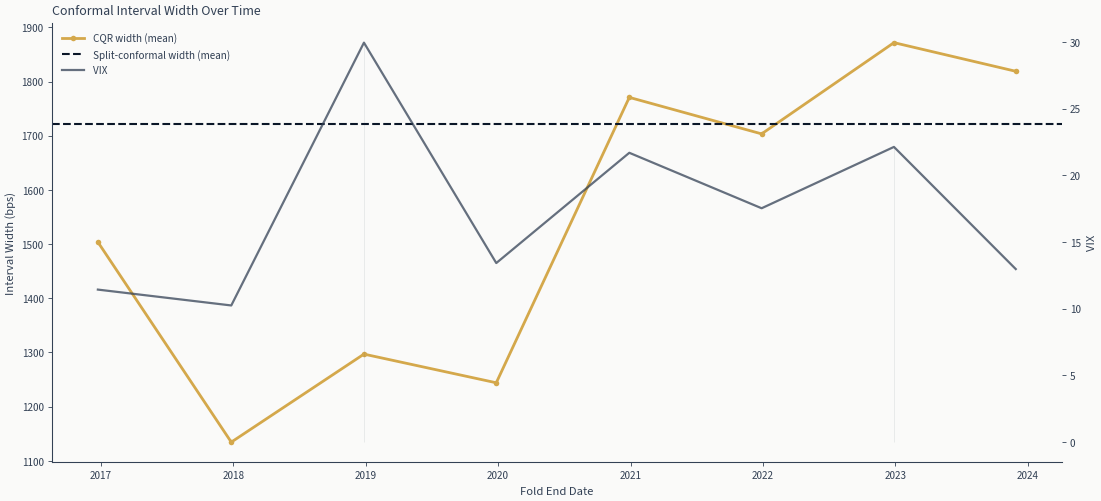

In [24]:
# Build the width-over-time figure in a single cell so the inline backend
# does not flush a partial figure before the twin-axis VIX overlay lands
# (see feedback_split_cell_figure_bug).
fold_stats = conformal_results.get("fold_stats", [])
if fold_stats:
    width_df = pl.DataFrame(fold_stats).sort("fold")
    plot_dates = pd.to_datetime(width_df["end"].to_list())
    sc_width_bps = width_df["sc_width_mean"].to_numpy() * 1e4
    cqr_width_bps = width_df["cqr_width_mean"].to_numpy() * 1e4

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.plot(plot_dates, cqr_width_bps, "o-", color=COLORS["amber"], lw=2, label="CQR width (mean)")
    ax1.axhline(
        y=float(np.mean(sc_width_bps)),
        color=COLORS["blue"],
        lw=1.5,
        ls="--",
        label="Split-conformal width (mean)",
    )
    ax1.set_xlabel("Fold End Date")
    ax1.set_ylabel("Interval Width (bps)")

    # Fetch the VIX overlay (falls back to |return| proxy if FRED unavailable).
    vol_label = "VIX"
    try:
        vix_df = load_macro(series=["vixcls"]).filter(pl.col("vixcls").is_not_null())
        vix_close = vix_df.to_pandas().set_index("timestamp")["vixcls"]
        vix_close.index = pd.to_datetime(vix_close.index).tz_localize(None)
        if vix_close.empty:
            raise ValueError("no VIX observations in FRED macro panel")
        vol_series = vix_close.reindex(plot_dates, method="ffill")
    except Exception as exc:
        proxy = (
            df.group_by("timestamp")
            .agg(pl.col(TARGET_COL).abs().mean().alias("vol_proxy"))
            .sort("timestamp")
            .to_pandas()
            .set_index("timestamp")["vol_proxy"]
        )
        proxy.index = pd.to_datetime(proxy.index).tz_localize(None)
        vol_series = proxy.reindex(plot_dates, method="ffill")
        vol_label = "Volatility Proxy"
        print(f"VIX unavailable ({exc}); using |return| volatility proxy.")

    # Overlay VIX on a twin axis and finalize.
    ax2 = ax1.twinx()
    ax2.plot(
        plot_dates, vol_series.values, color=COLORS["neutral"], lw=1.6, alpha=0.75, label=vol_label
    )
    high_vol = vol_series >= vol_series.quantile(0.75)
    ax2.fill_between(
        plot_dates,
        0,
        vol_series.values,
        where=high_vol.values,
        color=COLORS["neutral"],
        alpha=0.12,
        step="mid",
    )
    ax2.set_ylabel(vol_label)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

    ax1.set_title("Conformal Interval Width Over Time")
    plt.show()

**Interpretation**: CQR intervals have higher variance (wider during volatile
periods), which is desirable for risk-aware position sizing. Split-conformal
and ACI produce near-constant widths since they use the same base Ridge model.

## Conditional Coverage: Volatility Stratification

Marginal coverage (90% overall) can mask conditional failures. If intervals
are too narrow during volatile periods, the model under-covers precisely
when uncertainty matters most. We stratify by realized volatility (|return|)
terciles and check coverage within each.

In [25]:
# |return| was recorded inside the fold loop, so it is aligned with `covered` row for row.
vol_arr = np.array(conformal_results["vol_proxy"])
n_covered = len(conformal_results["sc"]["covered"])
assert len(vol_arr) == n_covered, (
    f"vol_proxy ({len(vol_arr):,}) and covered ({n_covered:,}) disagree, so the two were "
    "not recorded in the same pass over the folds. The cache signature above should have "
    f"caught that; if this fires, delete {display_path(RESULTS_PATH)} and re-run."
)

In [26]:
tercile_edges = np.quantile(vol_arr, [1 / 3, 2 / 3])
tercile = np.digitize(vol_arr, tercile_edges)  # 0=low, 1=mid, 2=high

rows = []
for method in ["sc", "cqr", "aci"]:
    cov_arr = np.array(conformal_results[method]["covered"])
    label = {"sc": "Split-Conformal", "cqr": "CQR", "aci": "ACI"}[method]
    row = {"Method": label, "Marginal": f"{cov_arr.mean():.1%}"}
    for t, name in enumerate(["Low", "Mid", "High"]):
        mask = tercile == t
        row[name] = f"{cov_arr[mask].mean():.1%}" if mask.sum() > 0 else "N/A"
    rows.append(row)

print("Coverage by volatility tercile (|return| proxy):\n")
tercile_table = pl.DataFrame(rows)
tercile_table

Coverage by volatility tercile (|return| proxy):



Method,Marginal,Low,Mid,High
str,str,str,str,str
"""Split-Conformal""","""88.6%""","""99.6%""","""99.0%""","""67.1%"""
"""CQR""","""89.3%""","""99.5%""","""98.1%""","""70.2%"""
"""ACI""","""89.6%""","""99.8%""","""99.4%""","""69.5%"""


**Interpretation**: this is the most important table in the notebook, and it
undoes the comfortable reading of the marginal numbers.

All three methods land within 2 pp of the 90% target marginally. Conditionally,
all three are broken in the same place. Every method covers ~99% in the two
low-volatility terciles and collapses to **66-70% in the high-volatility
tercile** — a nominal 10% failure rate delivering better than 30%. The marginal
90% is not a compromise between the terciles so much as an average of
over-covering where nothing is at stake and under-covering where everything is.

The adaptive methods do not rescue this. CQR's quantile models and ACI's online
feedback both buy about 3 pp in the high tercile over split-conformal, and cost
width elsewhere. Neither approaches 90% where volatility is high, because
neither is conditioning on the thing that matters: all three draw their
correction from a calibration set pooled across regimes, so the interval a
forecast receives during a volatility spike is set mostly by the quiet days that
dominate the calibration sample.

This is precisely the failure Section 11.5 names — *"coverage below 80% during
volatility spikes, for a 90% target, indicates that the calibration distribution
is stale or poorly stratified"* — and the response it prescribes is not a
different conformal variant but **regime-conditional calibration**: partition the
calibration scores by an ex-ante market state and compute a separate correction
within each.

For Chapter 19 the consequence is direct and uncomfortable. A strategy that
scales positions by interval width is relying on width to be honest exactly when
it is least honest. Sizing off these intervals would take the largest positions,
relative to true uncertainty, in the highest-volatility regime.

**Method note**: `|return|` is a crude regime proxy, and it is contaminated —
it is built from the realized outcome the interval is trying to cover, so the
high tercile partly selects for large residuals by construction. It is used here
because it needs no extra data. A production diagnostic should stratify on an
*ex-ante* state (trailing realized volatility, VIX level) known at decision time.
The direction of the finding is robust to this; the exact magnitudes are not.

In [27]:
# Save results
if NEED_TRAINING:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(conformal_results, RESULTS_PATH)
    print(f"Saved results to {display_path(RESULTS_PATH)}")

Saved results to 11_ml_pipeline/models/06_conformal_prediction/conformal_results.joblib


## Bridge to Position Sizing

Conformal intervals translate directly into position sizes: wider intervals
mean more uncertainty, warranting smaller positions. This simple inverse
relationship previews the full framework in Chapter 19.

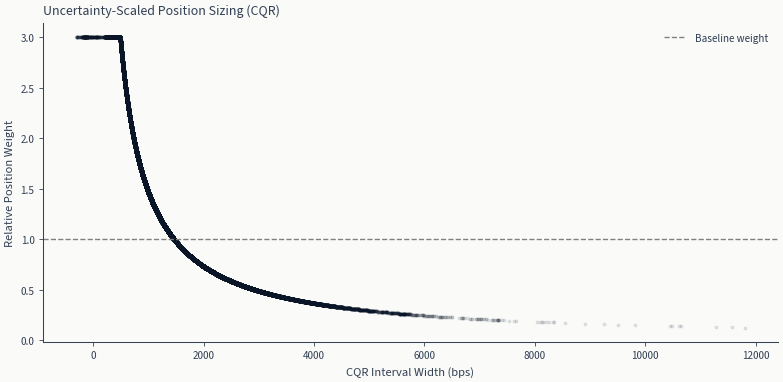

In [28]:
# Simple inverse-width position sizing using CQR intervals from last fold
cqr_widths = np.array(conformal_results["cqr"]["widths"])
# Avoid division by zero; use median width as reference
median_width = np.median(cqr_widths)
position_weight = median_width / np.maximum(cqr_widths, 1e-10)
position_weight = np.clip(position_weight, 0, 3)  # Cap at 3x median

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(cqr_widths * 1e4, position_weight, alpha=0.1, s=5)
ax.set_xlabel("CQR Interval Width (bps)")
ax.set_ylabel("Relative Position Weight")
ax.set_title("Uncertainty-Scaled Position Sizing (CQR)")
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, label="Baseline weight")
ax.legend()
fig.tight_layout()
plt.show()

Predictions with narrow intervals (high model confidence) receive larger
positions, while wide intervals (high uncertainty) reduce exposure. Chapter 19
integrates this with volatility forecasts and correlation estimates for
full portfolio construction.

## Key Takeaways

1. **Split-conformal** provides valid coverage with minimal assumptions and is
   trivial to implement: fit a model, compute residuals on a held-out calibration
   set, take the quantile as interval half-width. It requires only exchangeability
   of calibration and test data — a weaker condition than Gaussianity.

2. **CQR** produces adaptive intervals that widen during volatile periods, making
   it more suitable for uncertainty-aware position sizing (Chapter 19). The
   cost is fitting two quantile regressors (computationally heavier) instead of one.

3. **ACI** handles distribution shift by online-updating the miscoverage rate
   $\hat{\alpha}_t$ — but "online" has to mean what the trading problem allows.
   On a panel, one $\hat{\alpha}_t$ serves every asset at a decision timestamp,
   and feedback waits for the label to resolve (21 sessions here). Updating per
   row instead would let one ETF's realized return set another's interval at the
   same timestamp, and would consume outcomes three weeks before they exist. The
   resulting coverage would be a report on information the method never had.

4. All three methods land near the 90% target on the ETF dataset, and all three
   under-cover (88.3 / 89.1 / 89.5%) because walk-forward evaluation breaks the
   exchangeability the marginal guarantee assumes. **But the marginal number is
   the least interesting one here.** Stratified by volatility tercile, every
   method covers ~99% on quiet days and only 66-70% on volatile ones. A method
   can hit its marginal target and still fail, in the same direction, in the only
   regime where the interval was load-bearing. Always check stratified coverage;
   the fix is regime-conditional calibration, not a different conformal variant.

5. **Connection to portfolio construction**: Prediction intervals map directly
   to position sizes via an inverse-width rule. Wider intervals → smaller
   positions → automatic risk reduction when the model is uncertain. Chapter 19
   integrates this with volatility forecasts for full Kelly-style sizing. Carry
   takeaway 4 with you: this rule inherits the conditional-coverage gap, so it is
   least reliable exactly when position sizing matters most.

**Next**: `07_case_study_insights` compares linear model performance across all nine case studies.
**Book**: Section 11.5 discusses conformal prediction theory and practical deployment.